# Crop Yield Prediction in Kenya (2000–2023)

## Exploratory Data Analysis (EDA)

This notebook performs the initial exploration of the datasets used to develop a machine learning model for predicting crop yield in Kenya.

### Objectives

- Load all datasets
- Inspect their structure and contents
- Assess data quality by checking for missing values and duplicates
- Prepare the datasets for further preprocessing and modelling

The datasets used in this project are:

1. FAOSTAT agricultural statistics
2. NDVI (Normalized Difference Vegetation Index)
3. Annual Rainfall
4. Annual Land Surface Temperature

In [21]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all dataframe columns
pd.set_option("display.max_columns", None)

# Display wider tables
pd.set_option("display.width", 1000)

## Load the Datasets

The raw datasets are stored in the `Data/Raw_data` folder and are loaded into pandas DataFrames for analysis.

In [22]:
# Load Raw Datasets

faostat_df = pd.read_csv("../Data/Raw_data/Faostat.csv")

ndvi_df = pd.read_csv("../Data/Raw_data/NDVI.csv")

rainfall_df = pd.read_csv("../Data/Raw_data/Rainfall.csv")

temperature_df = pd.read_csv("../Data/Raw_data/Temperature.csv")

print("All datasets loaded successfully.")

All datasets loaded successfully.


## Dataset Inspection

This section examines the structure and contents of each dataset. We inspect the dimensions, column names, data types, and the first few records to understand the data before performing any cleaning or transformation.

In [26]:
# Inspect the Datasets

datasets = {
    "FAOSTAT": faostat_df,
    "NDVI": ndvi_df,
    "Rainfall": rainfall_df,
    "Temperature": temperature_df
}

for dataset_name, dataset_df in datasets.items():

    print("=" * 20)
    print(dataset_name)
    print("=" * 20)

    print(f"Shape: {dataset_df.shape}")

    print("\nColumns:")
    print(dataset_df.columns.tolist())

    print("\nData Types:")
    print(dataset_df.dtypes)

    print("\nFirst Five Rows:")
    display(dataset_df.head())

    print("\n")

FAOSTAT
Shape: (375, 5)

Columns:
['Item', 'Element', 'Year', 'Unit', 'Value']

Data Types:
Item           str
Element        str
Year         int64
Unit           str
Value      float64
dtype: object

First Five Rows:


,Item,Element,Year,Unit,Value
0,Rice,Area harvested,2000,ha,13882.0
1,Rice,Yield,2000,kg/ha,3771.0
2,Rice,Production,2000,t,52349.0
3,Rice,Area harvested,2001,ha,13200.0
4,Rice,Yield,2001,kg/ha,3409.1




NDVI
Shape: (120, 3)

Columns:
['Crop', 'Weighted_Mean_NDVI', 'Year']

Data Types:
Crop                      str
Weighted_Mean_NDVI    float64
Year                    int64
dtype: object

First Five Rows:


,Crop,Weighted_Mean_NDVI,Year
0,Maize,0.518891,2000
1,Maize,0.567526,2001
2,Maize,0.567220,2002
3,Maize,0.573118,2003
4,Maize,0.559780,2004




Rainfall
Shape: (120, 3)

Columns:
['Crop', 'Rainfall_mm', 'Year']

Data Types:
Crop               str
Rainfall_mm    float64
Year             int64
dtype: object

First Five Rows:


,Crop,Rainfall_mm,Year
0,Maize,991.254323,2000
1,Maize,1241.764138,2001
2,Maize,1267.337974,2002
3,Maize,1135.643418,2003
4,Maize,1095.686872,2004




Temperature
Shape: (120, 3)

Columns:
['Crop', 'Weighted_Mean_Temperature_C', 'Year']

Data Types:
Crop                               str
Weighted_Mean_Temperature_C    float64
Year                             int64
dtype: object

First Five Rows:


,Crop,Weighted_Mean_Temperature_C,Year
0,Maize,31.868734,2000
1,Maize,30.316524,2001
2,Maize,29.997854,2002
3,Maize,30.491539,2003
4,Maize,30.388731,2004


## Data Quality Assessment

Before transforming the datasets, it is important to assess their quality. This section checks for missing values and duplicate records in each dataset to identify potential issues that could affect the analysis and model performance.

In [27]:
# Assess Data Quality

datasets = {
    "FAOSTAT": faostat_df,
    "NDVI": ndvi_df,
    "Rainfall": rainfall_df,
    "Temperature": temperature_df
}

for dataset_name, dataset_df in datasets.items():

    print("=" * 20)
    print(dataset_name)
    print("=" * 20)

    print("\nMissing Values")
    print(dataset_df.isnull().sum())

    print("\nDuplicate Records")
    print(dataset_df.duplicated().sum())

    print("\n")

FAOSTAT

Missing Values
Item       0
Element    0
Year       0
Unit       0
Value      0
dtype: int64

Duplicate Records
0


NDVI

Missing Values
Crop                  0
Weighted_Mean_NDVI    0
Year                  0
dtype: int64

Duplicate Records
0


Rainfall

Missing Values
Crop           0
Rainfall_mm    0
Year           0
dtype: int64

Duplicate Records
0


Temperature

Missing Values
Crop                           0
Weighted_Mean_Temperature_C    0
Year                           0
dtype: int64

Duplicate Records
0




## Clean and Prepare the FAOSTAT Dataset

The FAOSTAT dataset is transformed into a machine-learning-ready format.

The following preprocessing steps are performed:

- Convert production values from tonnes (t) to kilograms (kg) for consistency.
- Pivot the dataset so that each row represents one crop in one year.
- Rename the pivoted columns to descriptive names.
- Arrange the dataset by Year and Crop to prepare it for merging with the NDVI, rainfall, and temperature datasets.

In [28]:
# Clean and Prepare the FAOSTAT Dataset

# Create a copy to preserve the original dataset
faostat_clean_df = faostat_df.copy()

# Convert production from tonnes to kilograms
production_mask = faostat_clean_df["Element"] == "Production"

faostat_clean_df.loc[production_mask, "Value"] = (
    faostat_clean_df.loc[production_mask, "Value"] * 1000
)

faostat_clean_df.loc[production_mask, "Unit"] = "kg"

# Pivot the dataset
faostat_clean_df = (
    faostat_clean_df
    .pivot(
        index=["Year", "Item"],
        columns="Element",
        values="Value"
    )
    .reset_index()
)

# Rename columns
faostat_clean_df = faostat_clean_df.rename(columns={
    "Item": "Crop",
    "Area harvested": "Harvested_Area_ha",
    "Production": "Production_kg",
    "Yield": "Yield_kg_per_ha"
})

# Arrange columns in the desired order
faostat_clean_df = faostat_clean_df[
    [
        "Year",
        "Crop",
        "Harvested_Area_ha",
        "Production_kg",
        "Yield_kg_per_ha"
    ]
]

# Sort by Year first, then Crop
faostat_clean_df = (
    faostat_clean_df
    .sort_values(
        by=["Year", "Crop"],
        ascending=[True, True]
    )
    .reset_index(drop=True)
)

print("FAOSTAT dataset prepared successfully.")

display(faostat_clean_df.head(15))

FAOSTAT dataset prepared successfully.


Element,Year,Crop,Harvested_Area_ha,Production_kg,Yield_kg_per_ha
0,2000,Maize (corn),1500000.0,2.160000e+09,1440.0
1,2000,Rice,13882.0,5.234900e+07,3771.0
2,2000,Sugar cane,57243.0,3.941524e+09,68856.0
3,2000,Tea leaves,120390.0,1.027000e+09,8530.6
4,2000,Wheat,131834.0,2.042320e+08,1549.2
5,2001,Maize (corn),1640000.0,2.790000e+09,1701.2
6,2001,Rice,13200.0,4.500000e+07,3409.1
7,2001,Sugar cane,47794.0,3.550792e+09,74293.7
8,2001,Tea leaves,124290.0,1.281000e+09,10306.5
9,2001,Wheat,129209.0,2.569970e+08,1989.0


## Standardize Crop Names

To ensure successful merging, crop names in the FAOSTAT dataset are standardized to match the NDVI, rainfall, and temperature datasets.

In [29]:
# Standardize Crop Names

crop_name_mapping = {
    "Maize (corn)": "Maize",
    "Sugar cane": "Sugarcane",
    "Tea leaves": "Tea"
}

faostat_clean_df["Crop"] = (
    faostat_clean_df["Crop"]
    .replace(crop_name_mapping)
)

print("Unique crop names:")

print(sorted(faostat_clean_df["Crop"].unique()))

Unique crop names:
['Maize', 'Rice', 'Sugarcane', 'Tea', 'Wheat']


## Merge the Datasets

The cleaned FAOSTAT dataset is merged with the NDVI, rainfall, and temperature datasets using the common keys **Crop** and **Year**. The resulting dataset will be used for exploratory data analysis and machine learning.

In [30]:
# Merge All Datasets

# Merge FAOSTAT with NDVI
merged_df = pd.merge(
    faostat_clean_df,
    ndvi_df,
    on=["Crop", "Year"],
    how="inner"
)

# Merge with Rainfall
merged_df = pd.merge(
    merged_df,
    rainfall_df,
    on=["Crop", "Year"],
    how="inner"
)

# Merge with Temperature
merged_df = pd.merge(
    merged_df,
    temperature_df,
    on=["Crop", "Year"],
    how="inner"
)

print("Datasets merged successfully.")

print(f"\nNumber of rows: {merged_df.shape[0]}")
print(f"Number of columns: {merged_df.shape[1]}")

display(merged_df.head(10))

Datasets merged successfully.

Number of rows: 120
Number of columns: 8


,Year,Crop,Harvested_Area_ha,Production_kg,Yield_kg_per_ha,Weighted_Mean_NDVI,Rainfall_mm,Weighted_Mean_Temperature_C
0,2000,Maize,1500000.0,2.160000e+09,1440.0,0.518891,991.254323,31.868734
1,2000,Rice,13882.0,5.234900e+07,3771.0,0.552471,850.924221,30.684194
2,2000,Sugarcane,57243.0,3.941524e+09,68856.0,0.597615,1355.680401,30.743833
3,2000,Tea,120390.0,1.027000e+09,8530.6,0.602310,1111.508038,28.538675
4,2000,Wheat,131834.0,2.042320e+08,1549.2,0.518453,835.072341,28.969239
5,2001,Maize,1640000.0,2.790000e+09,1701.2,0.567526,1241.764138,30.316524
6,2001,Rice,13200.0,4.500000e+07,3409.1,0.590736,1242.024533,28.883785
7,2001,Sugarcane,47794.0,3.550792e+09,74293.7,0.631959,1643.924375,29.970129
8,2001,Tea,124290.0,1.281000e+09,10306.5,0.647247,1448.844004,26.938514
9,2001,Wheat,129209.0,2.569970e+08,1989.0,0.604928,1170.410494,26.066822


## Save the Processed Dataset

The cleaned and merged dataset is saved to the `Data/Processed_data` folder for use in the exploratory data analysis, modelling, and evaluation notebooks.

In [31]:
# Save the Processed Dataset

output_path = "../Data/Processed_data/Crop_Yield_Kenya.csv"

merged_df.to_csv(output_path, index=False)

print("Processed dataset saved successfully.")
print(f"Location: {output_path}")

Processed dataset saved successfully.
Location: ../Data/Processed_data/Crop_Yield_Kenya.csv


In [32]:
# Verify the saved dataset

processed_df = pd.read_csv("../Data/Processed_data/Crop_Yield_Kenya.csv")

print(processed_df.shape)

processed_df.head()

(120, 8)


,Year,Crop,Harvested_Area_ha,Production_kg,Yield_kg_per_ha,Weighted_Mean_NDVI,Rainfall_mm,Weighted_Mean_Temperature_C
0,2000,Maize,1500000.0,2.160000e+09,1440.0,0.518891,991.254323,31.868734
1,2000,Rice,13882.0,5.234900e+07,3771.0,0.552471,850.924221,30.684194
2,2000,Sugarcane,57243.0,3.941524e+09,68856.0,0.597615,1355.680401,30.743833
3,2000,Tea,120390.0,1.027000e+09,8530.6,0.602310,1111.508038,28.538675
4,2000,Wheat,131834.0,2.042320e+08,1549.2,0.518453,835.072341,28.969239


# Exploratory Data Analysis (EDA)

This section explores the cleaned and merged crop yield dataset. The objective is to understand the distribution of the variables, identify trends over time, examine relationships between environmental variables and crop yield, and detect any unusual patterns before developing machine learning models.

## Summary Statistics

Summary statistics provide an overview of the central tendency and variability of the numerical variables in the dataset.

In [33]:
# Summary Statistics

summary_statistics_df = merged_df.describe().round(2)

display(summary_statistics_df)

,Year,Harvested_Area_ha,Production_kg,Yield_kg_per_ha,Weighted_Mean_NDVI,Rainfall_mm,Weighted_Mean_Temperature_C
count,120.00,120.00,1.200000e+02,120.00,120.00,120.00,120.00
mean,2011.50,476084.18,2.196620e+09,19362.27,0.61,1384.21,28.41
std,6.95,759517.53,2.138302e+09,30474.98,0.04,285.97,1.77
min,2000.00,10781.00,2.188100e+07,1258.10,0.51,835.07,24.85
25%,2005.75,56058.00,2.523978e+08,1932.30,0.58,1181.37,26.88
50%,2011.50,131479.50,1.689000e+09,3943.20,0.61,1320.71,28.51
75%,2017.25,220700.00,3.558594e+09,10310.35,0.64,1560.50,30.00
max,2023.00,2430014.00,8.799800e+09,93858.40,0.71,2437.47,32.06


### 5.1 Correlation Analysis

A correlation matrix was computed to examine the strength and direction of relationships among the numerical variables in the dataset.

In [36]:
# Select only numerical variables from the merged dataset
numerical_features_df = merged_df.select_dtypes(include="number")

# Calculate the Pearson correlation matrix
correlation_matrix_df = numerical_features_df.corr()

# Display the correlation matrix
correlation_matrix_df.round(2)

,Year,Harvested_Area_ha,Production_kg,Yield_kg_per_ha,Weighted_Mean_NDVI,Rainfall_mm,Weighted_Mean_Temperature_C
Year,1.00,0.08,0.17,-0.01,0.19,0.40,-0.18
Harvested_Area_ha,0.08,1.00,0.25,-0.31,-0.57,-0.17,0.51
Production_kg,0.17,0.25,1.00,0.79,0.04,0.57,0.56
Yield_kg_per_ha,-0.01,-0.31,0.79,1.00,0.24,0.58,0.39
Weighted_Mean_NDVI,0.19,-0.57,0.04,0.24,1.00,0.58,-0.57
Rainfall_mm,0.40,-0.17,0.57,0.58,0.58,1.00,-0.04
Weighted_Mean_Temperature_C,-0.18,0.51,0.56,0.39,-0.57,-0.04,1.00


## Correlation Analysis

The correlation matrix summarizes the linear relationships among the numerical variables in the dataset. Correlation coefficients range from -1 to 1, where values closer to 1 indicate a strong positive relationship, values closer to -1 indicate a strong negative relationship, and values near 0 indicate little or no linear relationship.

Interpretetion of the Correlation Analysis

In [40]:
print("""
Interpretation:

1. Rainfall_mm has a moderate positive correlation with Yield_kg_per_ha (0.58),
   suggesting that increased rainfall is generally associated with higher crop yields.

2. Weighted_Mean_Temperature_C has a weak to moderate positive correlation with
   Yield_kg_per_ha (0.39), indicating that temperature may influence crop productivity.

3. Weighted_Mean_NDVI has a weak positive correlation with Yield_kg_per_ha (0.24),
   suggesting that healthier vegetation is associated with slightly higher yields.

4. Harvested_Area_ha has a weak negative correlation with Yield_kg_per_ha (-0.31),
   indicating that larger cultivated areas do not necessarily result in higher yield per hectare.

5. No strong correlation exists among the predictor variables (above ±0.90),
   suggesting that severe multicollinearity is unlikely.

Note:
Production_kg is highly correlated with Yield_kg_per_ha (0.79), but it will not
be used as a predictor during model training because it is derived from yield
and harvested area, which could introduce data leakage.
""")


Interpretation:

1. Rainfall_mm has a moderate positive correlation with Yield_kg_per_ha (0.58),
   suggesting that increased rainfall is generally associated with higher crop yields.

2. Weighted_Mean_Temperature_C has a weak to moderate positive correlation with
   Yield_kg_per_ha (0.39), indicating that temperature may influence crop productivity.

3. Weighted_Mean_NDVI has a weak positive correlation with Yield_kg_per_ha (0.24),
   suggesting that healthier vegetation is associated with slightly higher yields.

4. Harvested_Area_ha has a weak negative correlation with Yield_kg_per_ha (-0.31),
   indicating that larger cultivated areas do not necessarily result in higher yield per hectare.

5. No strong correlation exists among the predictor variables (above ±0.90),
   suggesting that severe multicollinearity is unlikely.

Note:
Production_kg is highly correlated with Yield_kg_per_ha (0.79), but it will not
be used as a predictor during model training because it is derived from yie

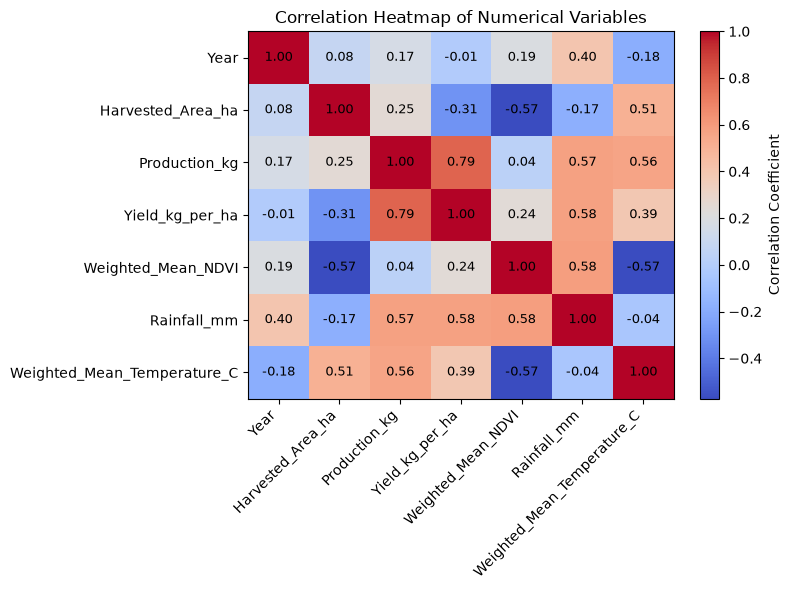

In [42]:
# Create a heatmap of the correlation matrix

plt.figure(figsize=(8, 6))

plt.imshow(
    correlation_matrix_df,
    cmap="coolwarm",
    interpolation="nearest",
    aspect="auto"
)

# Add correlation values to each cell
for row in range(len(correlation_matrix_df)):
    for column in range(len(correlation_matrix_df.columns)):
        plt.text(
            column,
            row,
            f"{correlation_matrix_df.iloc[row, column]:.2f}",
            ha="center",
            va="center",
            color="black",
            fontsize=9
        )

# Add color scale
plt.colorbar(label="Correlation Coefficient")

# Add axis labels
plt.xticks(
    range(len(correlation_matrix_df.columns)),
    correlation_matrix_df.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix_df.columns)),
    correlation_matrix_df.columns
)

plt.title("Correlation Heatmap of Numerical Variables")

plt.tight_layout()

# Save the figure
plt.savefig(
    "../figures/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

# Display the figure
plt.show()

## Trend Analysis

Trend analysis examines how crop yield has changed over time for each crop between 2000 and 2023. Visualizing these trends helps identify periods of increasing or decreasing productivity and highlights differences among the five crops included in the study.

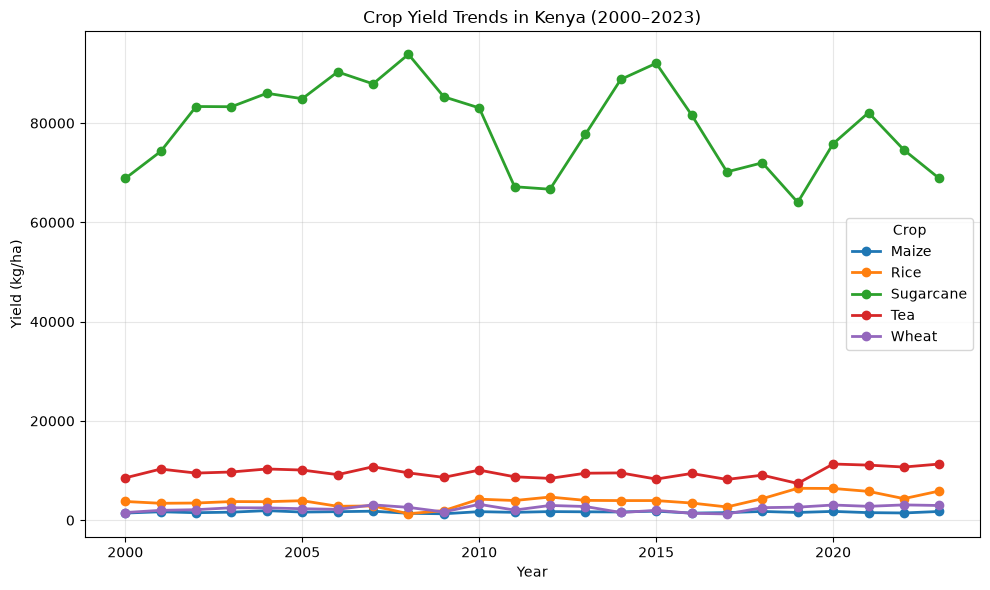

In [43]:
# Plot crop yield trends over time

plt.figure(figsize=(10, 6))

for crop_name in processed_df["Crop"].unique():

    crop_data = processed_df[processed_df["Crop"] == crop_name]

    plt.plot(
        crop_data["Year"],
        crop_data["Yield_kg_per_ha"],
        marker="o",
        linewidth=2,
        label=crop_name
    )

plt.title("Crop Yield Trends in Kenya (2000–2023)")
plt.xlabel("Year")
plt.ylabel("Yield (kg/ha)")

plt.legend(title="Crop")
plt.grid(alpha=0.3)

plt.tight_layout()

# Save the figure
plt.savefig(
    "../figures/yield_trends.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [48]:
print("""
Interpretation:

1. Sugarcane records the highest yield throughout the study period (2000–2023),
   ranging between approximately 64,000 and 94,000 kg/ha.

2. Tea consistently has the second-highest yield, remaining relatively stable
   between about 7,500 and 11,500 kg/ha.

3. Rice generally produces higher yields than maize and wheat, with noticeable
   increases after 2018.

4. Maize and wheat have the lowest yields among the five crops and exhibit
   greater year-to-year variability.

5. The figure highlights substantial differences in yield magnitude across crops,
   making it difficult to compare maize, rice, wheat, and tea because the much
   larger sugarcane values dominate the vertical axis.
""")


Interpretation:

1. Sugarcane records the highest yield throughout the study period (2000–2023),
   ranging between approximately 64,000 and 94,000 kg/ha.

2. Tea consistently has the second-highest yield, remaining relatively stable
   between about 7,500 and 11,500 kg/ha.

3. Rice generally produces higher yields than maize and wheat, with noticeable
   increases after 2018.

4. Maize and wheat have the lowest yields among the five crops and exhibit
   greater year-to-year variability.

5. The figure highlights substantial differences in yield magnitude across crops,
   making it difficult to compare maize, rice, wheat, and tea because the much
   larger sugarcane values dominate the vertical axis.



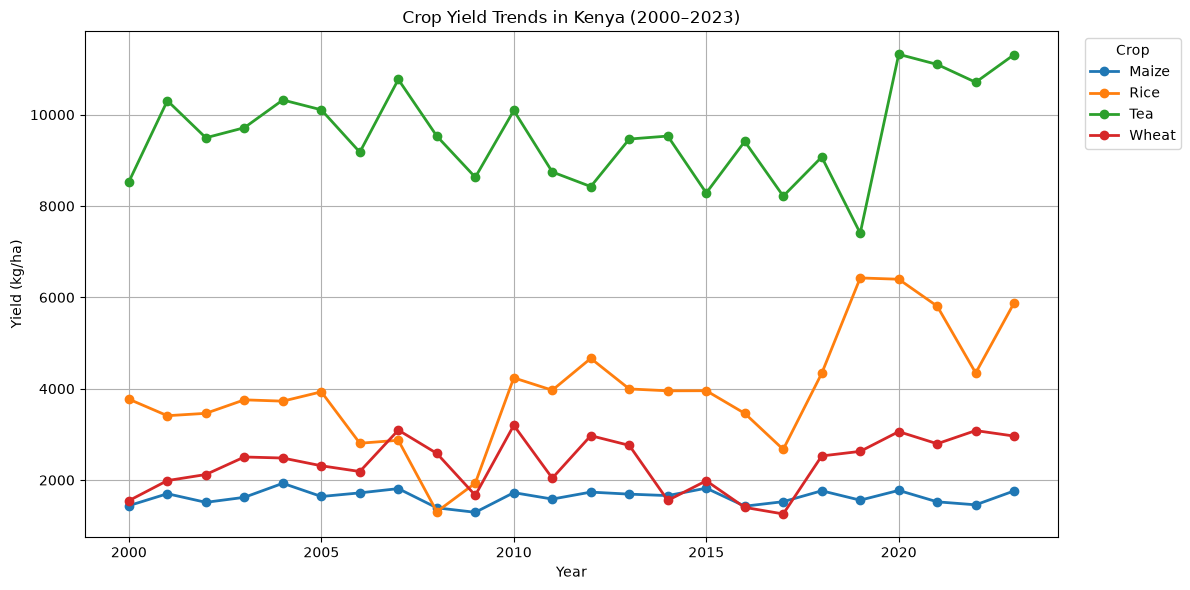

In [47]:
import matplotlib.pyplot as plt

# Exclude Sugarcane
yield_trends_df = processed_df[
    processed_df["Crop"] != "Sugarcane"
]

plt.figure(figsize=(12, 6))

for crop_name in yield_trends_df["Crop"].unique():
    crop_data = yield_trends_df[
        yield_trends_df["Crop"] == crop_name
    ]

    plt.plot(
        crop_data["Year"],
        crop_data["Yield_kg_per_ha"],
        marker="o",
        linewidth=2,
        label=crop_name
    )

plt.title("Crop Yield Trends in Kenya (2000–2023)")
plt.xlabel("Year")
plt.ylabel("Yield (kg/ha)")
plt.legend(
    title="Crop",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.grid(True)

plt.tight_layout()

# Save figure
plt.savefig(
    "../figures/yield_trends_without_sugarcane.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [50]:
print("""
Interpretation:

1. Excluding sugarcane improves the visibility of yield trends for maize, rice,
   tea, and wheat.

2. Tea maintains the highest yield among the remaining crops and shows a notable
   increase from 2020 onwards.

3. Rice exhibits considerable variability, with a marked improvement after 2018.

4. Wheat fluctuates substantially over the study period but generally improves
   after 2018.

5. Maize has the lowest yield among the four crops and remains relatively stable
   with only moderate year-to-year fluctuations.

6. This visualization provides a clearer comparison of crop performance than the
   full plot because the crops are displayed on a similar scale.
""")


Interpretation:

1. Excluding sugarcane improves the visibility of yield trends for maize, rice,
   tea, and wheat.

2. Tea maintains the highest yield among the remaining crops and shows a notable
   increase from 2020 onwards.

3. Rice exhibits considerable variability, with a marked improvement after 2018.

4. Wheat fluctuates substantially over the study period but generally improves
   after 2018.

5. Maize has the lowest yield among the four crops and remains relatively stable
   with only moderate year-to-year fluctuations.

6. This visualization provides a clearer comparison of crop performance than the
   full plot because the crops are displayed on a similar scale.



## Distribution of Numerical Variables (Histograms)

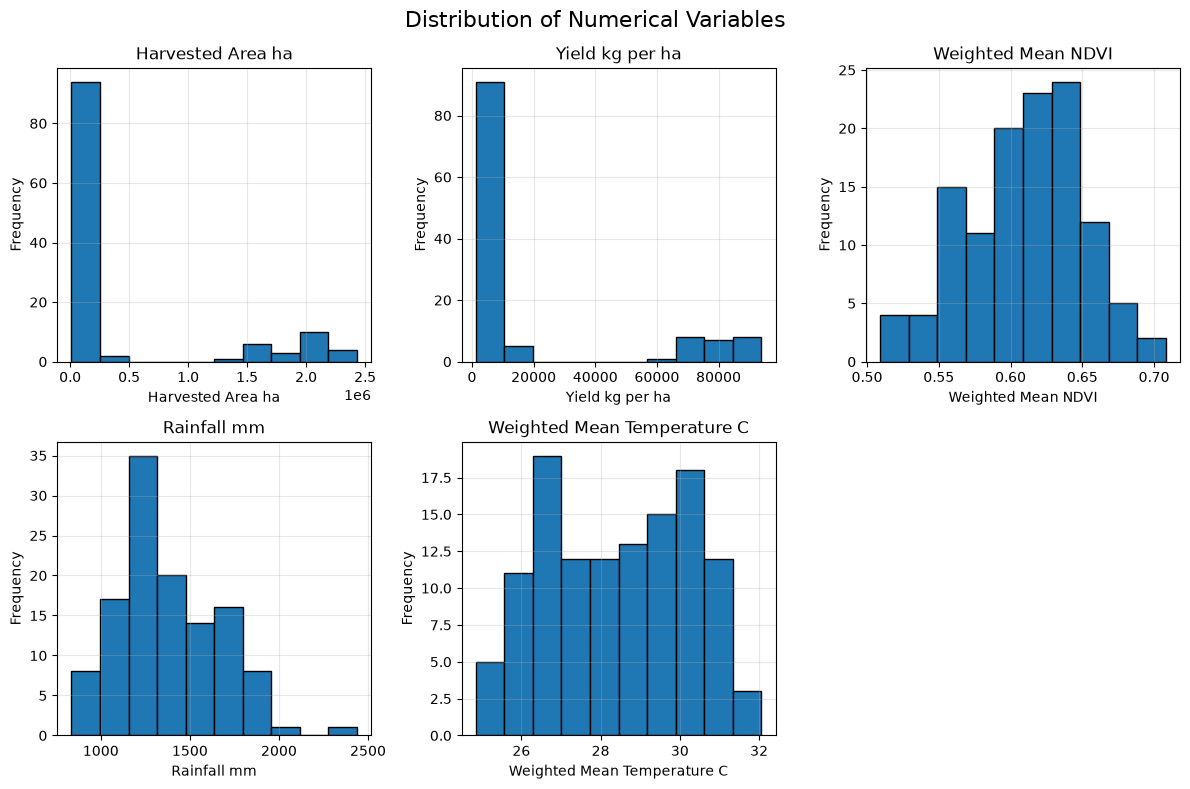

In [53]:
import matplotlib.pyplot as plt

# Variables to visualize
variables = [
    "Harvested_Area_ha",
    "Yield_kg_per_ha",
    "Weighted_Mean_NDVI",
    "Rainfall_mm",
    "Weighted_Mean_Temperature_C"
]

# Create figure
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

# Plot histograms
for ax, variable in zip(axes, variables):
    ax.hist(
        processed_df[variable],
        bins=10,
        edgecolor="black"
    )
    ax.set_title(variable.replace("_", " "))
    ax.set_xlabel(variable.replace("_", " "))
    ax.set_ylabel("Frequency")
    ax.grid(alpha=0.3)

plt.suptitle("Distribution of Numerical Variables", fontsize=16)
fig.delaxes(axes[5])
plt.tight_layout()

# Save figure
plt.savefig(
    "../figures/distribution_histograms.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Histogram Analysis

In [54]:
print("""
Interpretation:

1. Harvested_Area_ha is highly right-skewed because crop areas vary substantially across crops,
   with maize occupying much larger harvested areas than the others.

2. Yield_kg_per_ha is also highly right-skewed, largely due to the much higher yields observed
   for sugarcane compared to the other crops.

3. Weighted_Mean_NDVI is approximately normally distributed, indicating relatively consistent
   vegetation conditions across the study period.

4. Rainfall_mm shows slight positive skewness, with most observations receiving between
   1,100 mm and 1,700 mm of rainfall.

5. Weighted_Mean_Temperature_C has a fairly symmetric distribution, indicating relatively
   stable annual temperatures during the study period.
""")


Interpretation:

1. Harvested_Area_ha is highly right-skewed because crop areas vary substantially across crops,
   with maize occupying much larger harvested areas than the others.

2. Yield_kg_per_ha is also highly right-skewed, largely due to the much higher yields observed
   for sugarcane compared to the other crops.

3. Weighted_Mean_NDVI is approximately normally distributed, indicating relatively consistent
   vegetation conditions across the study period.

4. Rainfall_mm shows slight positive skewness, with most observations receiving between
   1,100 mm and 1,700 mm of rainfall.

5. Weighted_Mean_Temperature_C has a fairly symmetric distribution, indicating relatively
   stable annual temperatures during the study period.



##  Boxplots for Numerical Variables

C:\Users\Yvonne\AppData\Local\Temp\ipykernel_5588\3976652181.py:18: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(processed_df[variable], vert=True)
C:\Users\Yvonne\AppData\Local\Temp\ipykernel_5588\3976652181.py:18: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(processed_df[variable], vert=True)
C:\Users\Yvonne\AppData\Local\Temp\ipykernel_5588\3976652181.py:18: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(processed_df[variable], vert=True)
C:\Users\Yvonne\AppData\Local\Temp\ipykernel_5588\3976652181.py:18: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orien

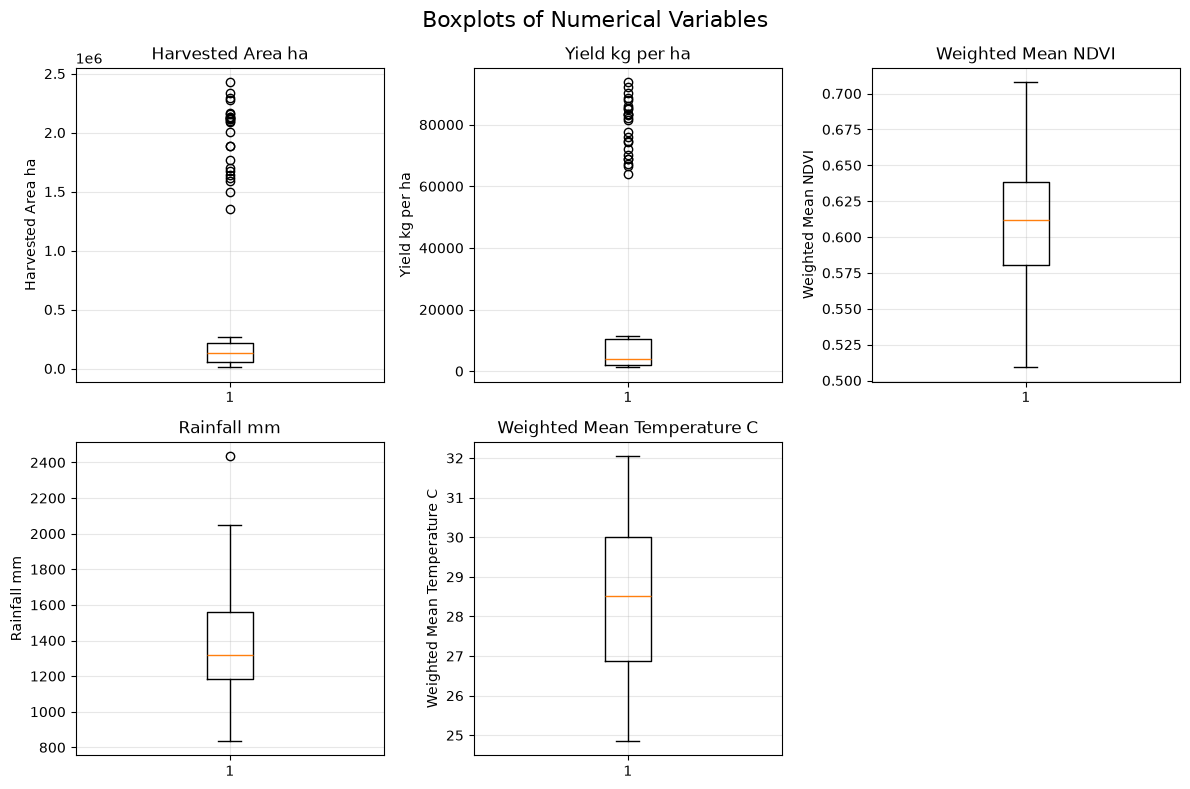

In [55]:
import matplotlib.pyplot as plt

# Variables to visualize
variables = [
    "Harvested_Area_ha",
    "Yield_kg_per_ha",
    "Weighted_Mean_NDVI",
    "Rainfall_mm",
    "Weighted_Mean_Temperature_C"
]

# Create figure
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

# Plot boxplots
for ax, variable in zip(axes, variables):
    ax.boxplot(processed_df[variable], vert=True)
    ax.set_title(variable.replace("_", " "))
    ax.set_ylabel(variable.replace("_", " "))
    ax.grid(alpha=0.3)

# Remove the unused subplot
fig.delaxes(axes[5])

plt.suptitle("Boxplots of Numerical Variables", fontsize=16)
plt.tight_layout()

# Save figure
plt.savefig(
    "../figures/boxplots_numerical_variables.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation of Boxplots

The boxplots summarize the spread, central tendency, and presence of potential outliers in the numerical variables used in the study.

In [56]:
print("""
Interpretation:

1. Harvested Area (ha)
   - The distribution is highly right-skewed with numerous upper outliers.
   - This indicates that a few crop-year observations have much larger harvested areas
     than the majority of observations.
   - This is expected because crops such as maize occupy substantially larger areas
     than crops like rice and tea.

2. Yield (kg/ha)
   - Yield also exhibits several high-value outliers.
   - These are primarily driven by crops with naturally higher yields,
     particularly sugarcane.
   - The variation reflects differences in biological characteristics across crops
     rather than data errors.

3. Weighted Mean NDVI
   - NDVI values are relatively concentrated around the median (~0.61),
     with no obvious extreme outliers.
   - This suggests vegetation greenness remained fairly consistent across
     crop locations and years.

4. Rainfall (mm)
   - Rainfall shows moderate variability with one noticeable high-value outlier
     above 2400 mm.
   - Most observations fall within a relatively narrow rainfall range,
     indicating generally consistent annual rainfall conditions.

5. Weighted Mean Temperature (°C)
   - Temperature values are evenly distributed with no significant outliers.
   - This indicates relatively stable annual temperature conditions
     across the study period.
""")


Interpretation:

1. Harvested Area (ha)
   - The distribution is highly right-skewed with numerous upper outliers.
   - This indicates that a few crop-year observations have much larger harvested areas
     than the majority of observations.
   - This is expected because crops such as maize occupy substantially larger areas
     than crops like rice and tea.

2. Yield (kg/ha)
   - Yield also exhibits several high-value outliers.
   - These are primarily driven by crops with naturally higher yields,
     particularly sugarcane.
   - The variation reflects differences in biological characteristics across crops
     rather than data errors.

3. Weighted Mean NDVI
   - NDVI values are relatively concentrated around the median (~0.61),
     with no obvious extreme outliers.
   - This suggests vegetation greenness remained fairly consistent across
     crop locations and years.

4. Rainfall (mm)
   - Rainfall shows moderate variability with one noticeable high-value outlier
     above 2400 

### Scatterplots for Predictor Variables vs Yield

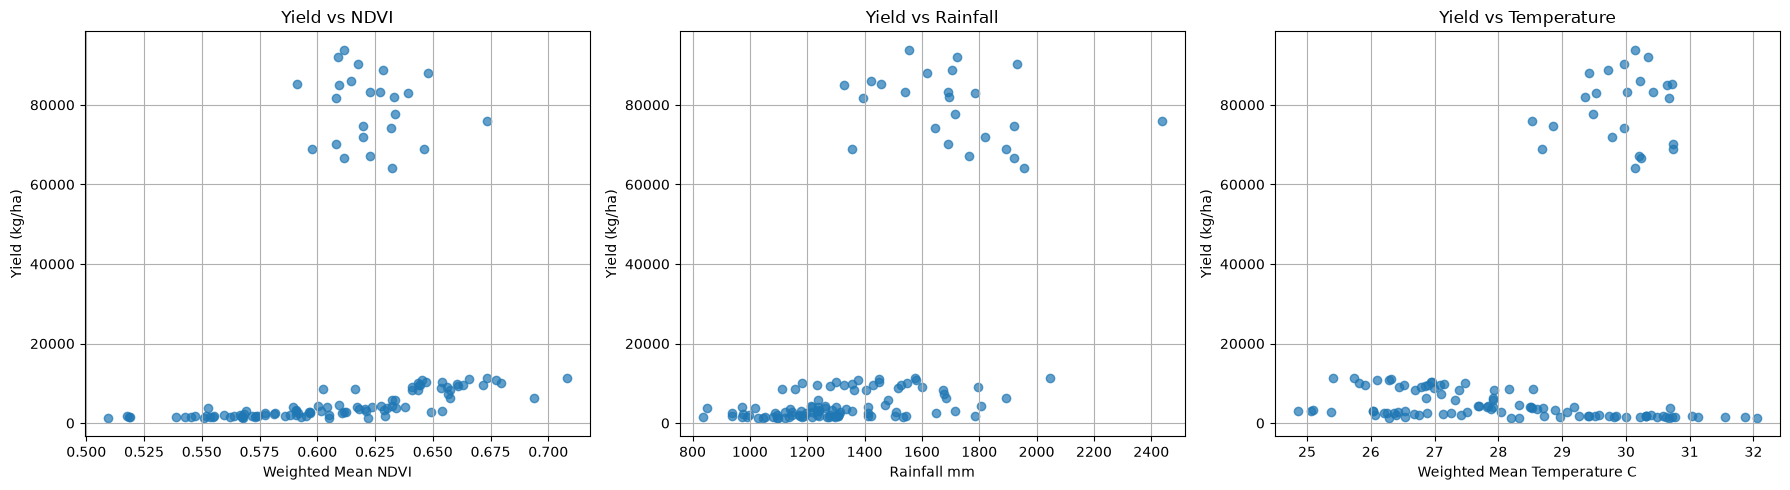

In [58]:
import matplotlib.pyplot as plt

predictors = [
    "Weighted_Mean_NDVI",
    "Rainfall_mm",
    "Weighted_Mean_Temperature_C"
]

titles = [
    "Yield vs NDVI",
    "Yield vs Rainfall",
    "Yield vs Temperature"
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, variable, title in zip(axes, predictors, titles):

    ax.scatter(
        processed_df[variable],
        processed_df["Yield_kg_per_ha"],
        alpha=0.7
    )

    ax.set_title(title)
    ax.set_xlabel(variable.replace("_", " "))
    ax.set_ylabel("Yield (kg/ha)")
    ax.grid(True)

plt.tight_layout()

plt.savefig(
    "../figures/yield_vs_predictors.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Interpreting the ScatterPlots

In [59]:
print("""
Interpretation:

1. Yield vs NDVI
   - A generally positive relationship is observed between NDVI and crop yield.
   - Higher NDVI values tend to be associated with higher yields, indicating that
     healthier vegetation is linked to improved crop productivity.
   - The relationship is not perfectly linear, suggesting that other factors also
     influence yield.

2. Yield vs Rainfall
   - Crop yield generally increases with rainfall up to a certain level.
   - Moderate to high rainfall appears beneficial for crop growth, although the
     spread of points indicates rainfall alone does not fully explain yield variation.

3. Yield vs Temperature
   - The relationship between temperature and yield is less pronounced.
   - Higher-yield observations tend to occur within a relatively narrow temperature
     range, suggesting that temperature influences yield but may interact with
     rainfall, vegetation condition, and crop type.

4. Yield vs Harvested Area
   - Harvested area does not show a clear linear relationship with yield.
   - This is expected because yield is measured as production per unit area
     (kg/ha) rather than total production.
   - Therefore, harvested area was explored during EDA but will not be used as a
     predictor in the final machine learning model, which focuses on environmental
     variables (NDVI, rainfall, and temperature).

Overall:
The scatterplots indicate that NDVI and rainfall exhibit the strongest positive
associations with crop yield, while temperature shows a weaker relationship.
These findings support selecting NDVI, rainfall, and temperature as the primary
predictor variables for yield prediction.
""")


Interpretation:

1. Yield vs NDVI
   - A generally positive relationship is observed between NDVI and crop yield.
   - Higher NDVI values tend to be associated with higher yields, indicating that
     healthier vegetation is linked to improved crop productivity.
   - The relationship is not perfectly linear, suggesting that other factors also
     influence yield.

2. Yield vs Rainfall
   - Crop yield generally increases with rainfall up to a certain level.
   - Moderate to high rainfall appears beneficial for crop growth, although the
     spread of points indicates rainfall alone does not fully explain yield variation.

3. Yield vs Temperature
   - The relationship between temperature and yield is less pronounced.
   - Higher-yield observations tend to occur within a relatively narrow temperature
     range, suggesting that temperature influences yield but may interact with
     rainfall, vegetation condition, and crop type.

4. Yield vs Harvested Area
   - Harvested area does not s

Boxplot of yield by Crop

<Figure size 800x600 with 0 Axes>

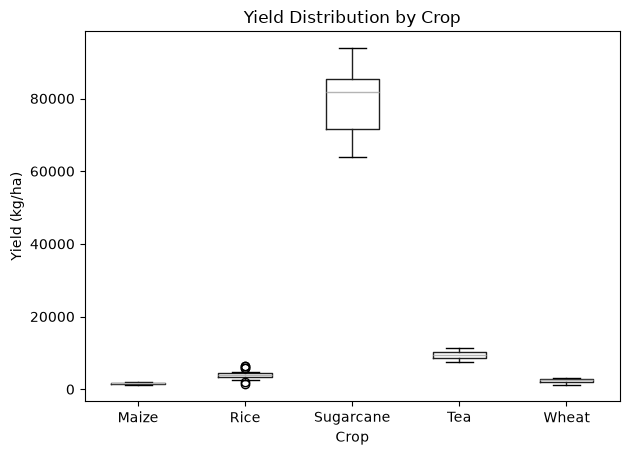

In [62]:
plt.figure(figsize=(8,6))

processed_df.boxplot(
    column="Yield_kg_per_ha",
    by="Crop",
    grid=False
)

plt.title("Yield Distribution by Crop")
plt.suptitle("")  # removes automatic subtitle
plt.xlabel("Crop")
plt.ylabel("Yield (kg/ha)")

plt.tight_layout()

plt.savefig(
    "../figures/yield_by_crop_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Interpreting Yield by Crop Results

In [63]:
print("""
Interpretation:

1. Yield varies substantially across crop types.

2. Sugarcane records the highest yield values, reflecting its naturally high biomass production.

3. Maize and wheat have comparatively lower yields than sugarcane, tea, and rice.

4. Differences in median yields and spread indicate that crop type is an important factor influencing yield.

5. The presence of outliers within some crops suggests that climatic conditions and management practices may vary across years.
""")


Interpretation:

1. Yield varies substantially across crop types.

2. Sugarcane records the highest yield values, reflecting its naturally high biomass production.

3. Maize and wheat have comparatively lower yields than sugarcane, tea, and rice.

4. Differences in median yields and spread indicate that crop type is an important factor influencing yield.

5. The presence of outliers within some crops suggests that climatic conditions and management practices may vary across years.



# Exploratory Data Analysis (EDA)

## Objective

The objective of this exploratory data analysis (EDA) is to understand the structure, quality, and characteristics of the Kenya Crop Yield dataset before developing machine learning models. This includes examining the dataset dimensions, data types, missing values, summary statistics, distributions of variables, and relationships between crop yield and environmental factors. The insights obtained from this analysis will guide data preprocessing, feature engineering, and model selection.

In [6]:
# Import Libraries & Load Dataset

# Import required libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display plots within the notebook
%matplotlib inline

# Set plot style
plt.style.use('ggplot')

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# Load dataset
df = pd.read_csv("../Data/Raw_data/Kenya_Crop_Yield_Dataset.csv")

# Display the first five rows
df.head()

,County,Crop,Year,Area_ha,Production_tons,Yield_t_ha,NDVI,Rainfall_mm,Temperature_C,Elevation_m,Slope_Degrees,Soil_Moisture,Evapotranspiration_mm
0,Baringo,Beans,2019,21020,19977,0.95038059,0.5218,1194.1247,32.2339,1396.4230,9.0675,0.1890,707.8706
1,Bomet,Beans,2019,32273,42592,1.31974096,0.6909,1701.3963,28.1587,1905.3299,5.5580,0.3890,1123.7098
2,Bungoma,Beans,2019,78930,56775,0.719308248,0.6323,2009.6689,30.1118,1553.9248,4.2350,0.3689,938.2848
3,Busia,Beans,2019,21083,21412,1.01560499,0.6342,2262.5101,30.6340,1229.2644,3.5520,0.3591,829.6820
4,Homa Bay,Beans,2019,48558,29696,0.611557313,0.6445,1885.0167,31.0128,1337.6682,4.0555,0.3431,924.3744


## Dataset Overview

This section examines the structure of the dataset, including the number of observations, variables, data types, and summary statistics. It also checks for missing values and duplicate records before further analysis.

In [7]:
# Dataset overview

print(f"Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns\n")

print("Data Types")
display(df.dtypes)

print("\nMissing Values")
display(df.isnull().sum())

print(f"\nDuplicate Rows: {df.duplicated().sum()}")

print("\nSummary Statistics")
display(df.describe())

Dataset Shape: 765 rows and 13 columns

Data Types


County                       str
Crop                         str
Year                       int64
Area_ha                    int64
Production_tons            int64
Yield_t_ha                   str
NDVI                     float64
Rainfall_mm              float64
Temperature_C            float64
Elevation_m              float64
Slope_Degrees            float64
Soil_Moisture            float64
Evapotranspiration_mm    float64
dtype: object


Missing Values


County                   0
Crop                     0
Year                     0
Area_ha                  0
Production_tons          0
Yield_t_ha               0
NDVI                     5
Rainfall_mm              5
Temperature_C            5
Elevation_m              5
Slope_Degrees            5
Soil_Moisture            5
Evapotranspiration_mm    5
dtype: int64


Duplicate Rows: 0

Summary Statistics


,Year,Area_ha,Production_tons,NDVI,Rainfall_mm,Temperature_C,Elevation_m,Slope_Degrees,Soil_Moisture,Evapotranspiration_mm
count,765.0000,765.0000,765.0000,760.0000,760.0000,760.0000,760.0000,760.0000,760.0000,760.0000
mean,2021.0000,22968.6732,46780.3229,0.5853,1439.2680,29.3510,1499.8519,6.0792,0.2969,861.7734
std,1.4151,31988.3904,85601.1392,0.1021,557.9715,3.3146,543.1669,2.3142,0.0768,219.5550
min,2019.0000,0.0000,0.0000,0.2484,260.9567,21.3275,16.2847,2.1349,0.1087,153.9554
25%,2020.0000,869.0000,2057.0000,0.5217,968.8335,26.8775,1247.5327,4.2475,0.2387,726.5147
50%,2021.0000,6680.0000,14069.0000,0.6088,1432.3484,29.2662,1463.8956,5.6067,0.3082,901.1841
75%,2022.0000,35005.0000,50853.0000,0.6592,1855.7976,31.7555,1905.1767,7.3885,0.3588,1030.4575
max,2023.0000,150726.0000,657091.0000,0.7606,3012.3126,42.1022,2607.0111,13.6676,0.4489,1323.1058


## Data Quality Assessment

This section converts the target variable to the correct data type and investigates records with missing environmental variables to determine the appropriate data cleaning strategy.

In [8]:
# Convert Yield to numeric
df["Yield_t_ha"] = pd.to_numeric(df["Yield_t_ha"], errors="coerce")

# Confirm data types
print("Updated Data Types")
display(df.dtypes)

# Display rows with missing values
print("Rows with Missing Values:")
display(df[df.isnull().any(axis=1)])

# Check if Yield has any missing values after conversion
print(f"Missing values in Yield_t_ha: {df['Yield_t_ha'].isnull().sum()}")

Updated Data Types


County                       str
Crop                         str
Year                       int64
Area_ha                    int64
Production_tons            int64
Yield_t_ha               float64
NDVI                     float64
Rainfall_mm              float64
Temperature_C            float64
Elevation_m              float64
Slope_Degrees            float64
Soil_Moisture            float64
Evapotranspiration_mm    float64
dtype: object

Rows with Missing Values:


,County,Crop,Year,Area_ha,Production_tons,Yield_t_ha,NDVI,Rainfall_mm,Temperature_C,Elevation_m,Slope_Degrees,Soil_Moisture,Evapotranspiration_mm
89,Lamu,Pigeon Peas,2019,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
241,Laikipia,Pigeon Peas,2020,0,35,NaN,0.5613,1049.1839,31.0218,1572.3059,8.5724,0.2640,763.0705
242,Lamu,Pigeon Peas,2020,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
394,Laikipia,Pigeon Peas,2021,0,28,NaN,0.3842,603.1207,35.7408,1572.3059,8.5724,0.2063,396.1240
395,Lamu,Pigeon Peas,2021,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
547,Laikipia,Pigeon Peas,2022,0,32,NaN,0.3483,518.3237,35.8988,1572.3059,8.5724,0.1865,377.4362
548,Lamu,Pigeon Peas,2022,530,318,0.6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
701,Lamu,Pigeon Peas,2023,500,300,0.6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Missing values in Yield_t_ha: 6


## Data Cleaning

Records with missing target values or missing environmental variables were removed. These observations could not be used for modelling because the target yield could not be calculated or the predictor variables were unavailable.

In [9]:
# Remove rows with any missing values
df = df.dropna().reset_index(drop=True)

# Verify dataset after cleaning
print(f"New dataset shape: {df.shape}")

print("\nMissing values")
display(df.isnull().sum())

print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Display first five rows
df.head()

New dataset shape: (757, 13)

Missing values


County                   0
Crop                     0
Year                     0
Area_ha                  0
Production_tons          0
Yield_t_ha               0
NDVI                     0
Rainfall_mm              0
Temperature_C            0
Elevation_m              0
Slope_Degrees            0
Soil_Moisture            0
Evapotranspiration_mm    0
dtype: int64


Duplicate rows: 0


,County,Crop,Year,Area_ha,Production_tons,Yield_t_ha,NDVI,Rainfall_mm,Temperature_C,Elevation_m,Slope_Degrees,Soil_Moisture,Evapotranspiration_mm
0,Baringo,Beans,2019,21020,19977,0.9504,0.5218,1194.1247,32.2339,1396.4230,9.0675,0.1890,707.8706
1,Bomet,Beans,2019,32273,42592,1.3197,0.6909,1701.3963,28.1587,1905.3299,5.5580,0.3890,1123.7098
2,Bungoma,Beans,2019,78930,56775,0.7193,0.6323,2009.6689,30.1118,1553.9248,4.2350,0.3689,938.2848
3,Busia,Beans,2019,21083,21412,1.0156,0.6342,2262.5101,30.6340,1229.2644,3.5520,0.3591,829.6820
4,Homa Bay,Beans,2019,48558,29696,0.6116,0.6445,1885.0167,31.0128,1337.6682,4.0555,0.3431,924.3744


## Distribution of Observations

This section examines how the observations are distributed across crops, counties, and years. Understanding the distribution helps identify whether the dataset is balanced and highlights any potential sampling bias that could influence model performance.

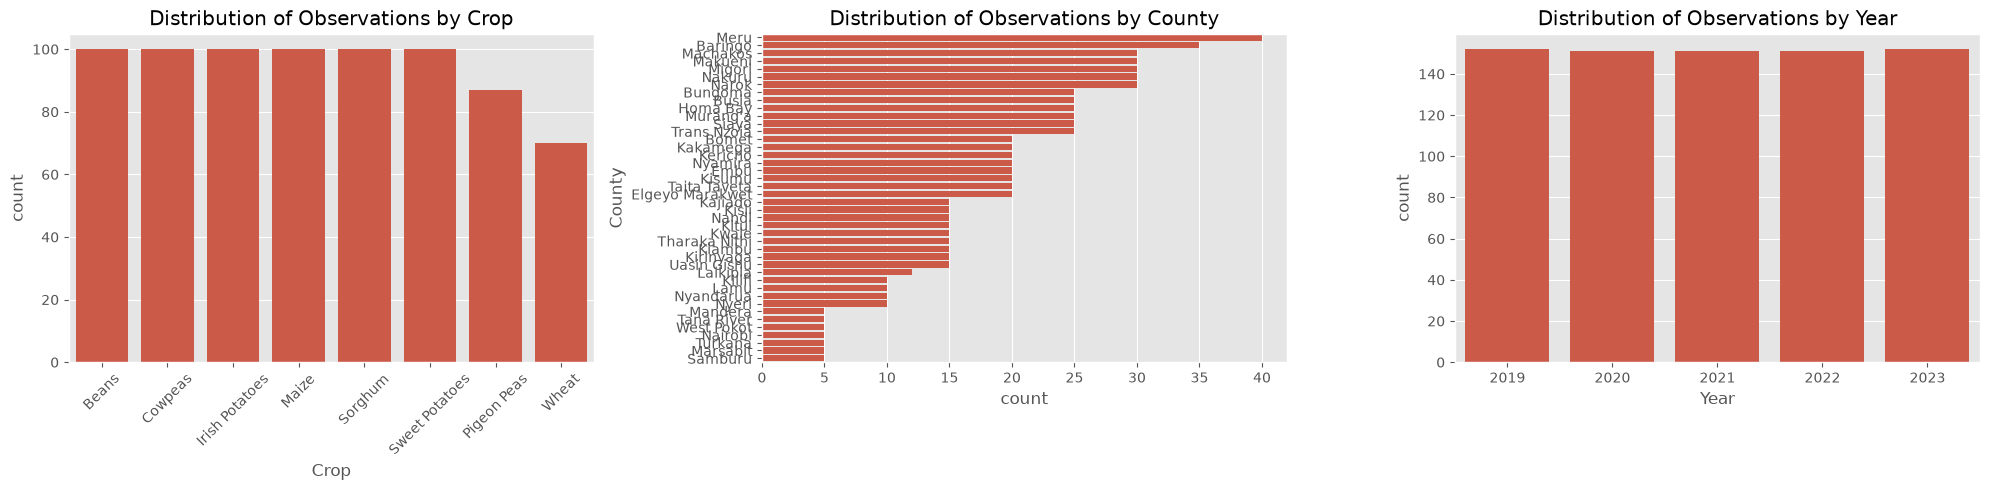

Crop Counts


Crop
Beans             100
Cowpeas           100
Irish Potatoes    100
Maize             100
Sorghum           100
Sweet Potatoes    100
Pigeon Peas        87
Wheat              70
Name: count, dtype: int64


County Counts


County
Meru               40
Baringo            35
Machakos           30
Makueni            30
Migori             30
Nakuru             30
Narok              30
Bungoma            25
Busia              25
Homa Bay           25
Murang'a           25
Siaya              25
Trans Nzoia        25
Bomet              20
Kakamega           20
Kericho            20
Nyamira            20
Embu               20
Kisumu             20
Taita Taveta       20
Elgeyo Marakwet    20
Kajiado            15
Kisii              15
Nandi              15
Kitui              15
Kwale              15
Tharaka Nithi      15
Kiambu             15
Kirinyaga          15
Uasin Gishu        15
Laikipia           12
Kilifi             10
Lamu               10
Nyandarua          10
Nyeri              10
Mandera             5
Tana River          5
West Pokot          5
Nairobi             5
Turkana             5
Marsabit            5
Samburu             5
Name: count, dtype: int64


Year Counts


Year
2019    152
2020    151
2021    151
2022    151
2023    152
Name: count, dtype: int64

In [11]:
# Distribution of observations

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Crop distribution
sns.countplot(
    data=df,
    x='Crop',
    order=df['Crop'].value_counts().index,
    ax=axes[0]
)
axes[0].set_title('Distribution of Observations by Crop')
axes[0].tick_params(axis='x', rotation=45)

# County distribution
sns.countplot(
    data=df,
    y='County',
    order=df['County'].value_counts().index,
    ax=axes[1]
)
axes[1].set_title('Distribution of Observations by County')

# Year distribution
sns.countplot(
    data=df,
    x='Year',
    order=sorted(df['Year'].unique()),
    ax=axes[2]
)
axes[2].set_title('Distribution of Observations by Year')

plt.tight_layout()

# Save figure
plt.savefig(
    "../figures/distribution_of_observations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Display frequency tables
print("Crop Counts")
display(df['Crop'].value_counts())

print("\nCounty Counts")
display(df['County'].value_counts())

print("\nYear Counts")
display(df['Year'].value_counts().sort_index())

### Distribution of Observations

The dataset contains 757 observations collected between 2019 and 2023 across eight major crops grown in Kenya.

Beans, Cowpeas, Irish Potatoes, Maize, Sorghum and Sweet Potatoes each contribute 100 observations, while Pigeon Peas (87) and Wheat (70) have fewer records because they are cultivated in fewer counties.
The distribution across years is nearly uniform, with approximately 151–152 observations per year, indicating good temporal balance.
County representation varies according to where each crop is grown. Meru has the highest number of observations (40), followed by Baringo (35), while counties such as Marsabit, Samburu, Turkana, Nairobi, Tana River and Mandera each contribute only five observations because fewer study crops are cultivated there.

Overall, the dataset is reasonably balanced across years and crops, although county representation differs based on crop distribution across Kenya.

## Distribution of Numerical Variables

This section examines the distribution of the numerical variables used in crop yield prediction. Histograms are used to visualize the frequency distribution of each variable, while boxplots help identify the spread of the data and the presence of potential outliers. Understanding these distributions is important for selecting appropriate preprocessing techniques and machine learning models.

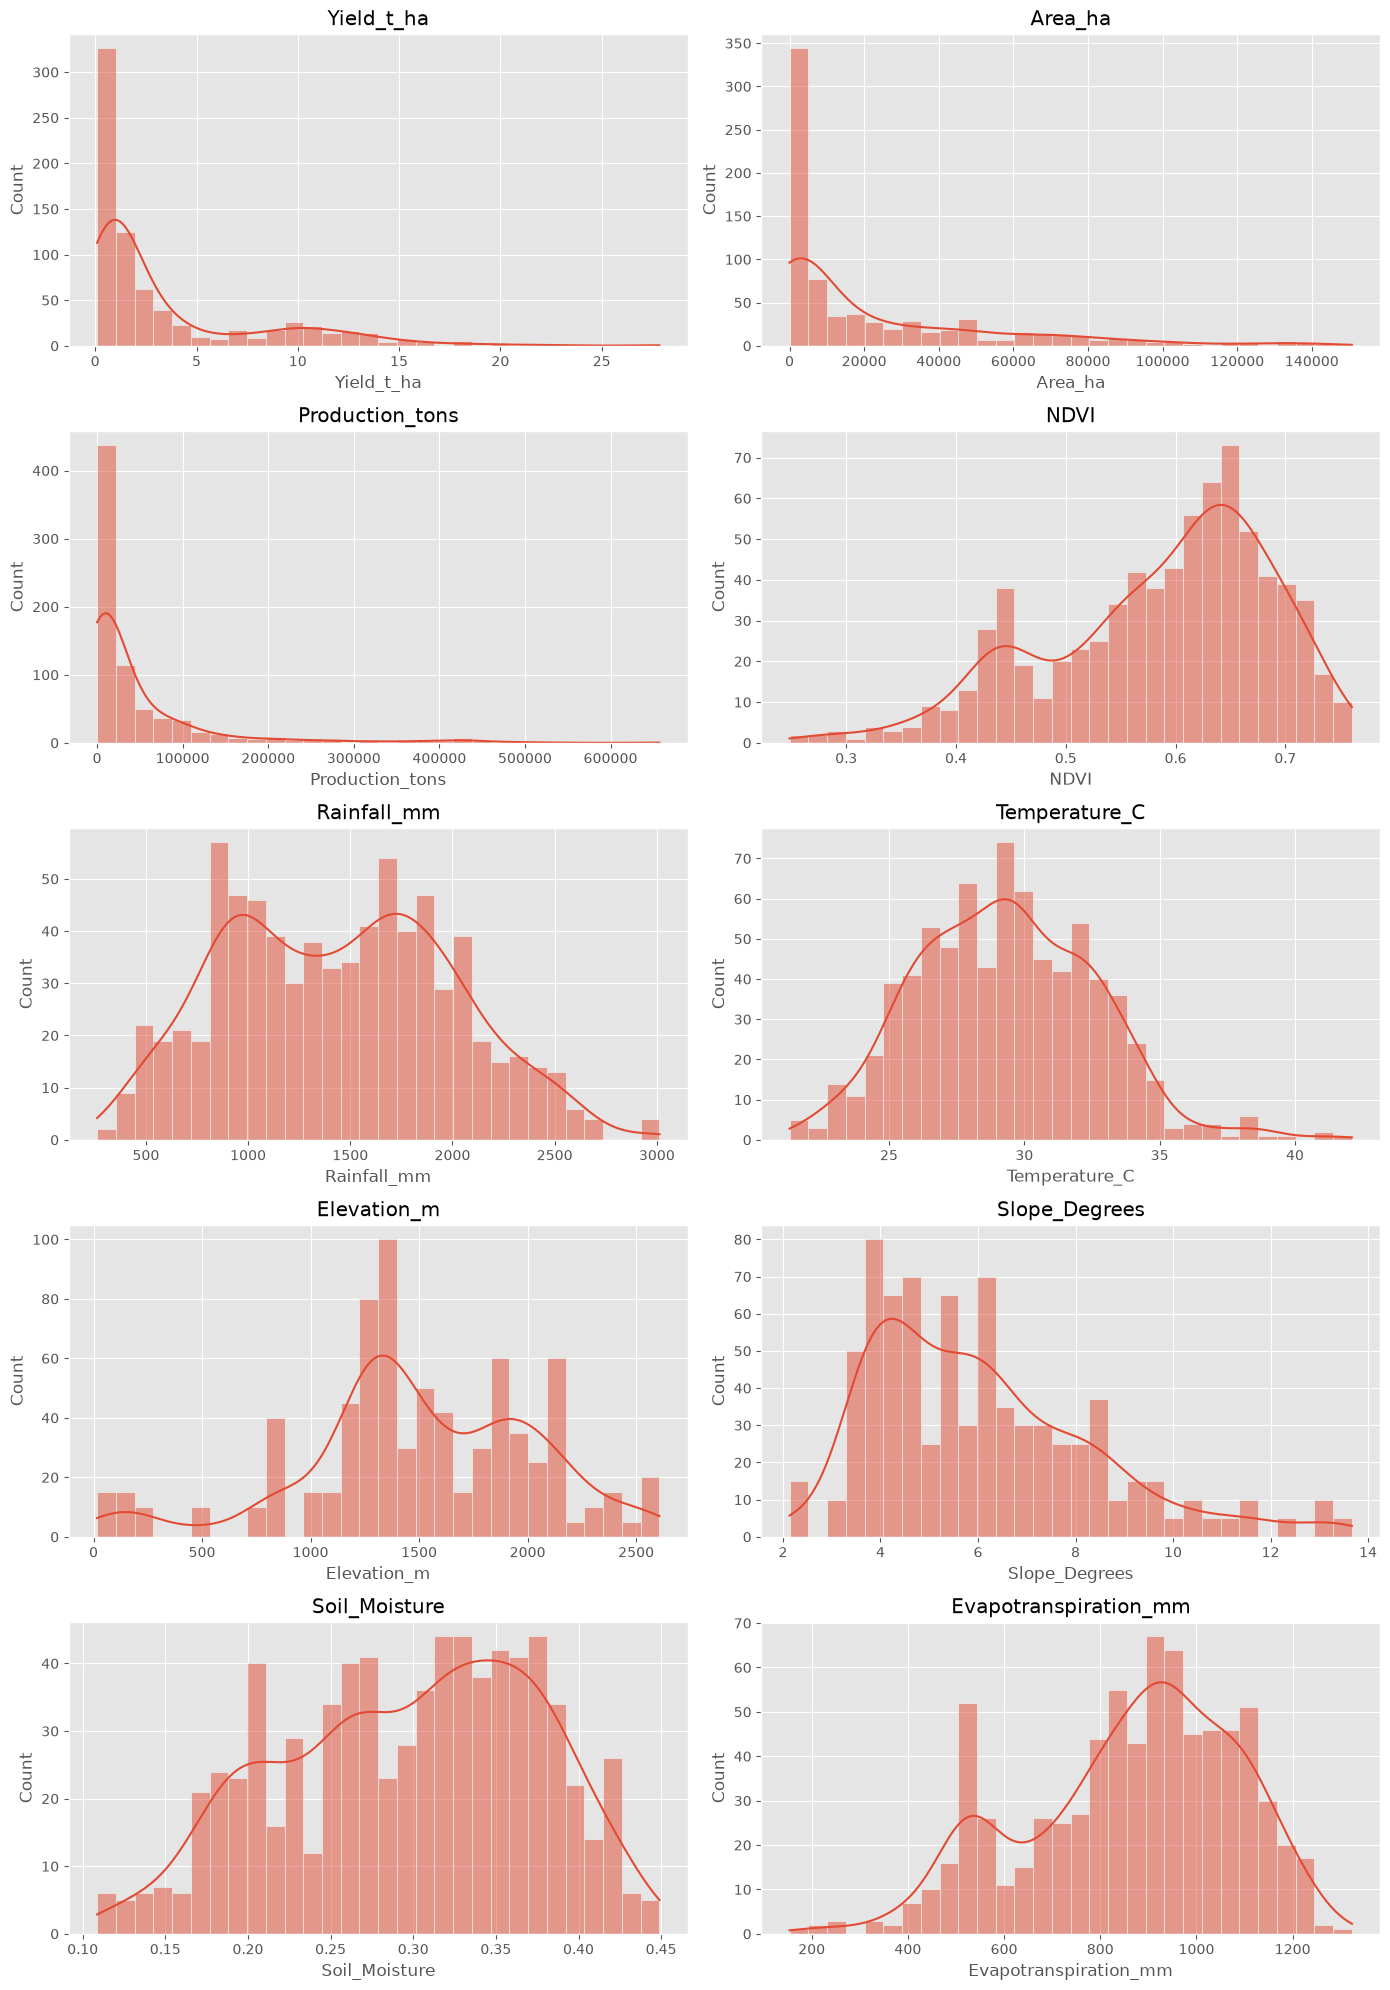

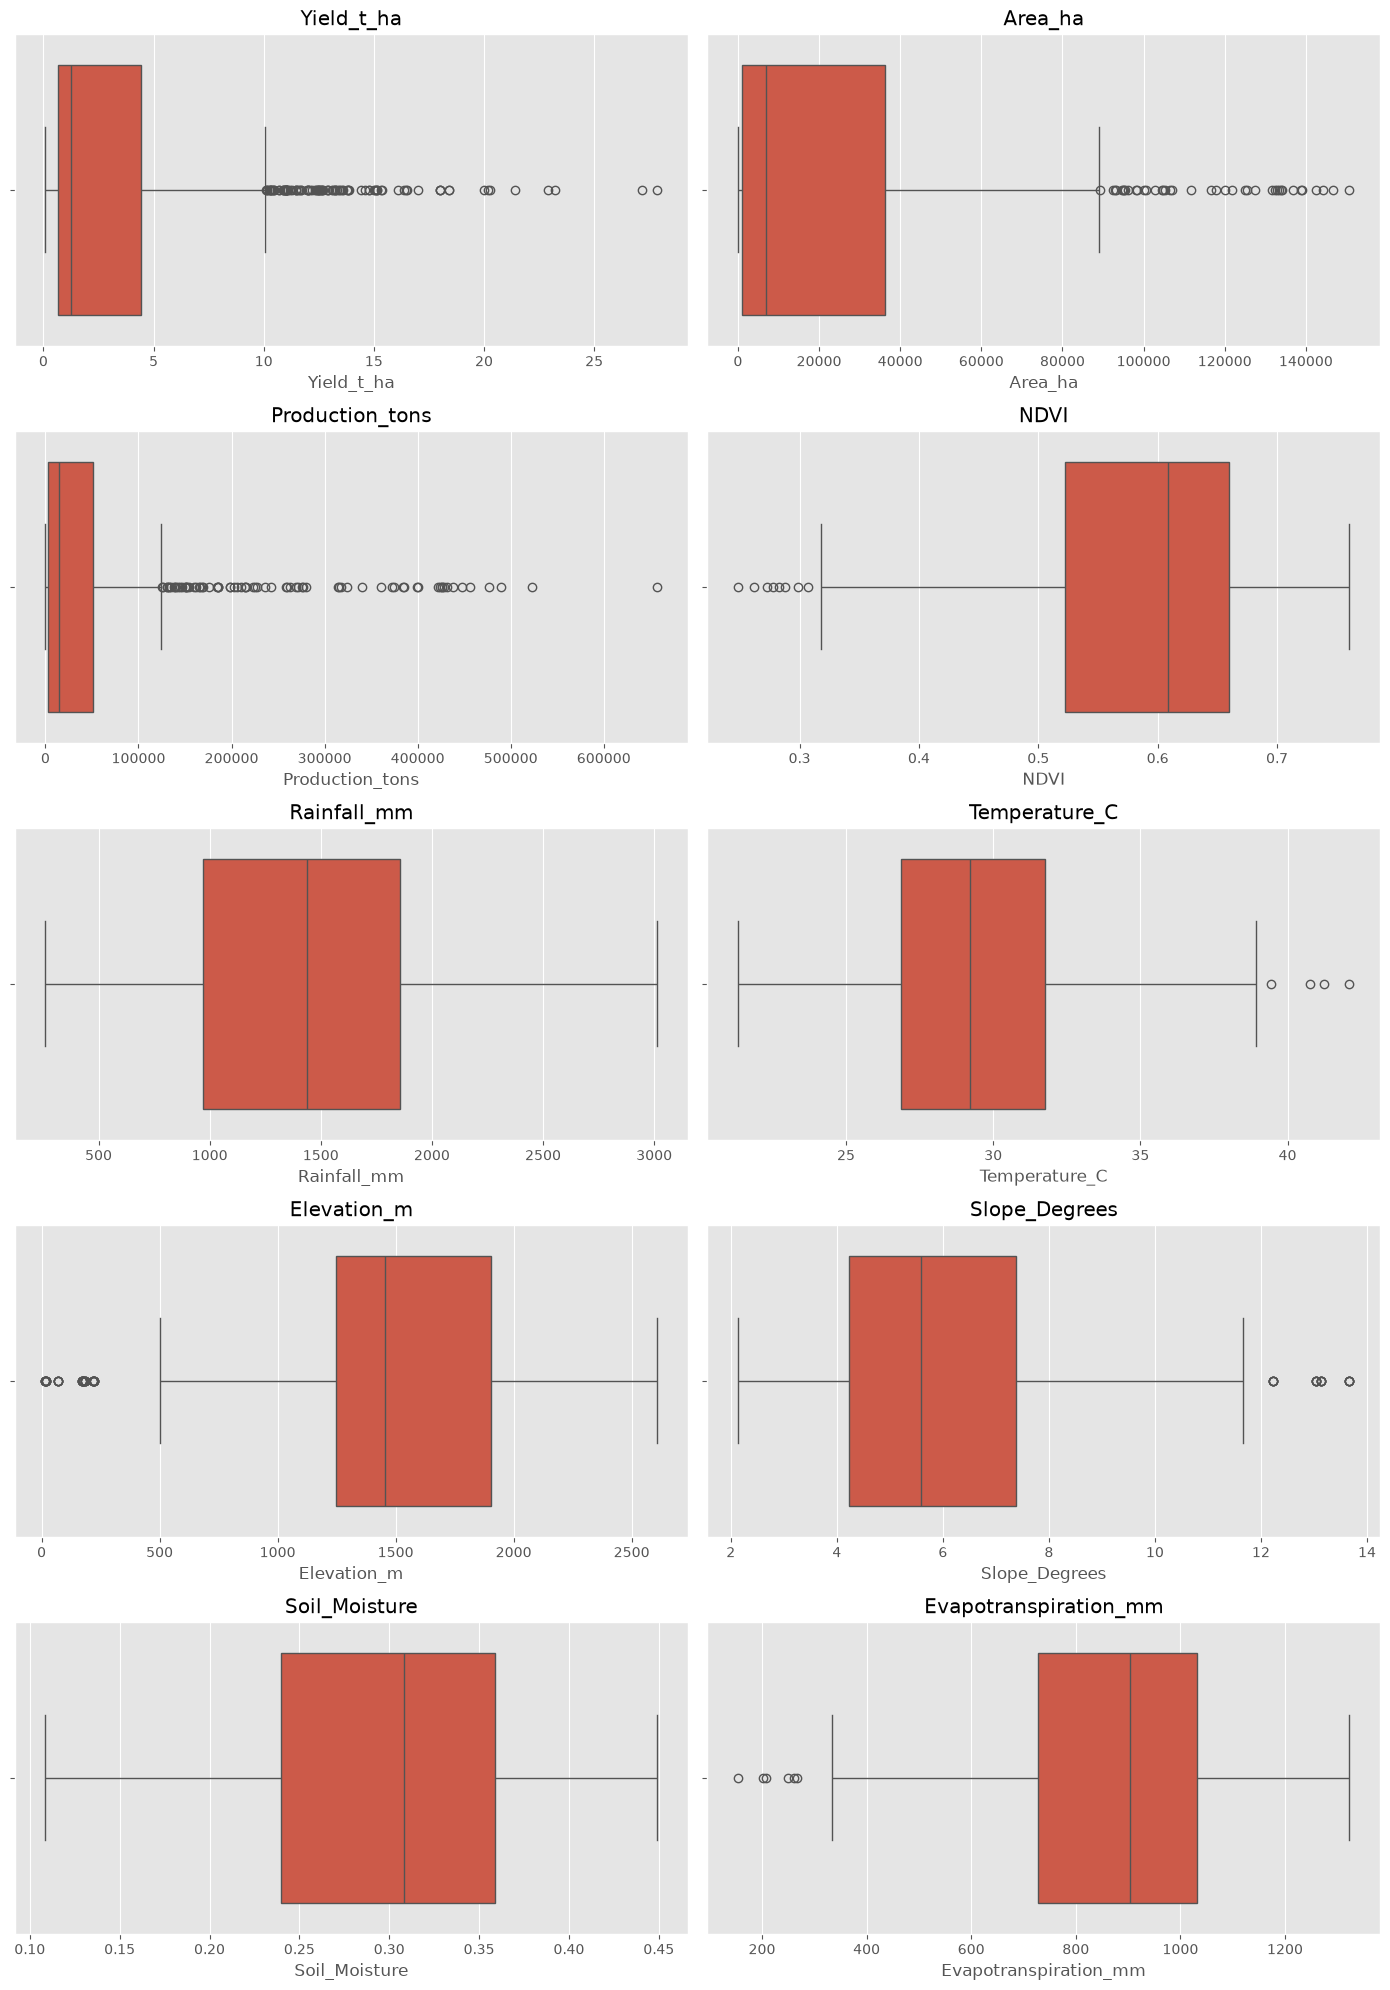

In [12]:
# Numerical variables
numerical_cols = [
    'Yield_t_ha',
    'Area_ha',
    'Production_tons',
    'NDVI',
    'Rainfall_mm',
    'Temperature_C',
    'Elevation_m',
    'Slope_Degrees',
    'Soil_Moisture',
    'Evapotranspiration_mm'
]

# Histograms
fig, axes = plt.subplots(5, 2, figsize=(14, 20))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()

plt.savefig(
    "../figures/numerical_variables_histograms.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Boxplots
fig, axes = plt.subplots(5, 2, figsize=(14, 20))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()

plt.savefig(
    "../figures/numerical_variables_boxplots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Distribution of Numerical Variables

The boxplots and histograms reveal the distribution and spread of the numerical variables in the dataset.

- **Yield (t/ha), Area (ha), and Production (tons)** are strongly right-skewed, with several high-value observations appearing as outliers. These extreme values are expected because crop production and cultivated area vary considerably across counties and crop types.

- **NDVI** is approximately normally distributed, with most observations ranging between 0.5 and 0.7, indicating moderate to healthy vegetation conditions across the study areas.

- **Rainfall** shows moderate variability, with values spanning approximately 300 mm to 3000 mm annually. The distribution is slightly skewed but does not contain many extreme outliers.

- **Temperature** is close to a normal distribution, with most counties recording annual average temperatures between 27°C and 32°C. Only a few high-temperature observations appear as outliers.

- **Elevation** exhibits a wide range, reflecting Kenya's diverse topography from low-lying coastal regions to highland areas.

- **Slope** is positively skewed, indicating that most agricultural areas occur on relatively gentle terrain, while a few counties contain steeper landscapes.

- **Soil Moisture** follows a fairly symmetric distribution centered around 0.30, suggesting moderate variation in moisture conditions.

- **Evapotranspiration** displays a near-normal distribution with moderate variability across counties and years.

Overall, the environmental variables (NDVI, rainfall, temperature, soil moisture, and evapotranspiration) exhibit relatively stable distributions, whereas the agricultural variables (yield, production, and cultivated area) contain substantial variability and several extreme values. These observations will be considered during data preprocessing and model development.

## Correlation Analysis

Correlation analysis was performed to examine the strength and direction of linear relationships among the numerical variables in the dataset. Understanding these relationships helps identify variables that may influence crop yield, detect potential multicollinearity among predictors, and provide insights for feature selection before model development.

Pearson's correlation coefficient, ranging from -1 to 1, was used to quantify the relationships between variables. Positive values indicate that two variables increase together, while negative values indicate that one variable decreases as the other increases.

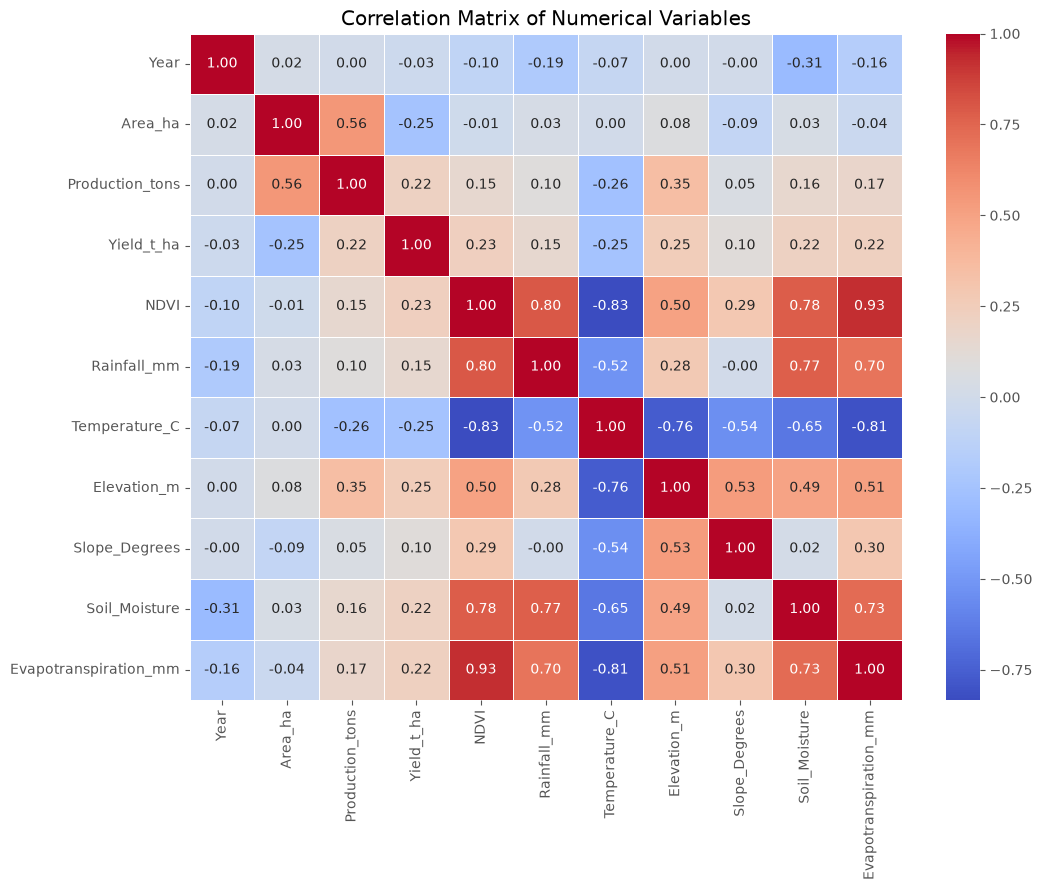

,Year,Area_ha,Production_tons,Yield_t_ha,NDVI,Rainfall_mm,Temperature_C,Elevation_m,Slope_Degrees,Soil_Moisture,Evapotranspiration_mm
Year,1.0000,0.0236,0.0006,-0.0301,-0.0968,-0.1899,-0.0682,0.0000,-0.0000,-0.3074,-0.1620
Area_ha,0.0236,1.0000,0.5556,-0.2484,-0.0134,0.0307,0.0000,0.0757,-0.0853,0.0338,-0.0418
Production_tons,0.0006,0.5556,1.0000,0.2171,0.1510,0.0962,-0.2633,0.3513,0.0493,0.1584,0.1711
Yield_t_ha,-0.0301,-0.2484,0.2171,1.0000,0.2263,0.1534,-0.2527,0.2547,0.1021,0.2188,0.2204
NDVI,-0.0968,-0.0134,0.1510,0.2263,1.0000,0.7967,-0.8339,0.5004,0.2854,0.7830,0.9265
Rainfall_mm,-0.1899,0.0307,0.0962,0.1534,0.7967,1.0000,-0.5196,0.2801,-0.0024,0.7708,0.6978
Temperature_C,-0.0682,0.0000,-0.2633,-0.2527,-0.8339,-0.5196,1.0000,-0.7649,-0.5444,-0.6489,-0.8112
Elevation_m,0.0000,0.0757,0.3513,0.2547,0.5004,0.2801,-0.7649,1.0000,0.5327,0.4940,0.5082
Slope_Degrees,-0.0000,-0.0853,0.0493,0.1021,0.2854,-0.0024,-0.5444,0.5327,1.0000,0.0172,0.2954
Soil_Moisture,-0.3074,0.0338,0.1584,0.2188,0.7830,0.7708,-0.6489,0.4940,0.0172,1.0000,0.7338


In [13]:
# Correlation Matrix

import os

# Numerical columns
numerical_cols = [
    'Year',
    'Area_ha',
    'Production_tons',
    'Yield_t_ha',
    'NDVI',
    'Rainfall_mm',
    'Temperature_C',
    'Elevation_m',
    'Slope_Degrees',
    'Soil_Moisture',
    'Evapotranspiration_mm'
]

# Compute correlation matrix
corr_matrix = df[numerical_cols].corr()

# Plot heatmap
plt.figure(figsize=(11,9))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()

# Save figure
os.makedirs("../figures", exist_ok=True)
plt.savefig("../figures/correlation_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

# Display correlation matrix
corr_matrix

## Correlation Analysis Interpretation

The correlation matrix shows the strength and direction of linear relationships between numerical variables.

Key observations include:

- Yield (Yield_t_ha) exhibits weak to moderate positive correlations with NDVI (0.23), Elevation (0.25), Soil Moisture (0.22), Evapotranspiration (0.22), and Production (0.22). These relationships suggest that improved vegetation condition, moisture availability, and favourable environmental conditions are associated with higher crop yields.

- Yield has a weak negative correlation with Temperature (-0.25), indicating that higher temperatures may reduce crop productivity. Yield also has a weak negative correlation with harvested area (-0.25), suggesting that larger cultivated areas do not necessarily produce higher yields per hectare.

- NDVI shows a very strong positive correlation with Evapotranspiration (0.93), a strong positive correlation with Rainfall (0.80), and a strong positive correlation with Soil Moisture (0.78). These relationships are expected because healthier vegetation generally occurs under adequate moisture conditions.

- Temperature is strongly negatively correlated with NDVI (-0.83), Evapotranspiration (-0.81), and Elevation (-0.76), indicating that cooler, higher-elevation regions tend to support healthier vegetation and greater moisture availability.

Overall, the environmental variables demonstrate logical relationships with one another. Although Yield_t_ha is not strongly correlated with any single predictor, this is expected because crop yield is influenced by multiple interacting factors. This supports the use of machine learning models capable of capturing nonlinear relationships among predictors.

## Crop-wise Yield Analysis

This analysis compares the distribution of crop yields across the eight crop types in the dataset.

Boxplots are used to examine differences in median yield, variability, and potential outliers among crops. Since each crop has unique biological characteristics and management practices, yield distributions are expected to differ considerably.

Understanding these differences helps identify high- and low-yielding crops and provides insights into crop-specific variability before model development.

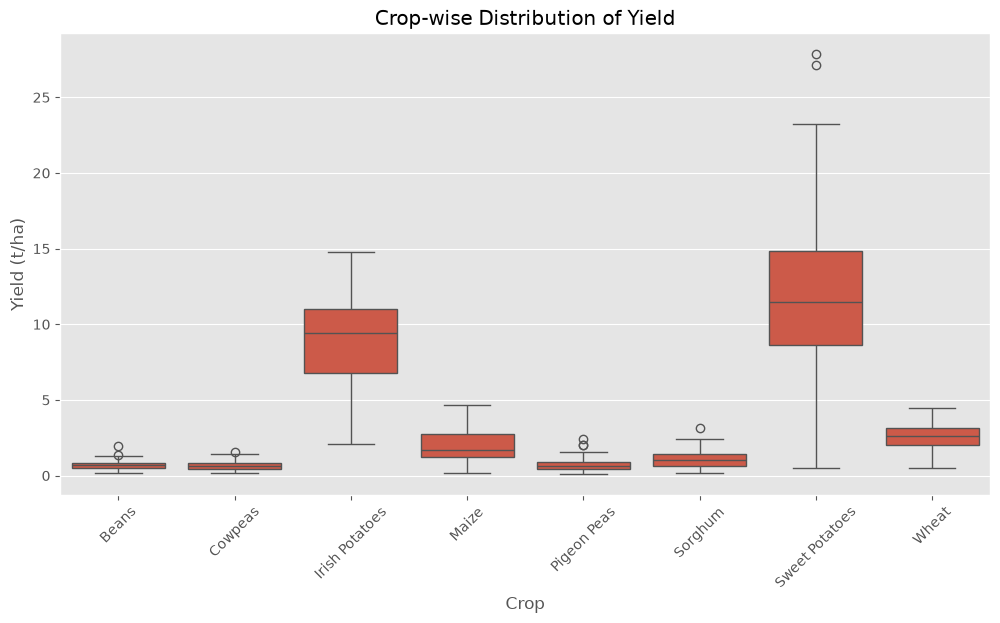

,count,mean,median,std,min,max
Crop,,,,,,
Beans,100,0.7000,0.6900,0.2700,0.1700,1.9700
Cowpeas,100,0.6700,0.6100,0.3000,0.2000,1.5600
Irish Potatoes,100,8.8200,9.4500,2.8500,2.1000,14.7600
Maize,100,1.9800,1.7000,1.0200,0.1700,4.6600
Pigeon Peas,87,0.7200,0.6700,0.4000,0.0900,2.4000
Sorghum,100,1.0900,1.0400,0.5300,0.1800,3.1500
Sweet Potatoes,100,11.9100,11.4600,5.0800,0.5100,27.8500
Wheat,70,2.5700,2.6400,0.9800,0.5000,4.5000


In [14]:
# Crop-wise Yield Analysis

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x='Crop',
    y='Yield_t_ha'
)

plt.title('Crop-wise Distribution of Yield')
plt.xlabel('Crop')
plt.ylabel('Yield (t/ha)')
plt.xticks(rotation=45)

# Save figure
plt.savefig("../figures/cropwise_yield_boxplot.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

# Summary statistics by crop
crop_summary = (
    df.groupby("Crop")["Yield_t_ha"]
      .agg(["count","mean","median","std","min","max"])
      .round(2)
)

display(crop_summary)

## Crop-wise Yield Analysis

This analysis compares the distribution of yield across the eight crop types using boxplots and summary statistics. It helps identify differences in productivity, variability, and potential outliers between crops.

### Interpretation
- Sweet potatoes recorded the highest average yield (11.91 t/ha), followed by Irish potatoes (8.82 t/ha). This is expected because root and tuber crops naturally produce much higher yields per hectare than cereal and legume crops.
- Wheat (2.57 t/ha) and maize (1.98 t/ha) had moderate yields, while beans (0.70 t/ha), cowpeas (0.67 t/ha), pigeon peas (0.72 t/ha), and sorghum (1.09 t/ha) recorded comparatively lower yields.
- Sweet potatoes exhibited the greatest variability (standard deviation = 5.08 t/ha), indicating considerable differences in productivity across counties and years. Irish potatoes also showed substantial variability (standard deviation = 2.85 t/ha).
- Several high-yield outliers are visible for sweet potatoes, while the remaining crops contain relatively few outliers. These observations are agriculturally plausible and were retained because they likely reflect genuine differences rather than data entry errors.
- The unequal number of observations for wheat (70) and pigeon peas (87), compared with 100 observations for most other crops, reflects differences in county-level production rather than missing records.

## Temporal (Yearly) Trends

This section examines how crop yield has changed over time by comparing the average yield for each year. The analysis helps identify overall trends, annual variability, and whether yields have generally increased or decreased during the study period.

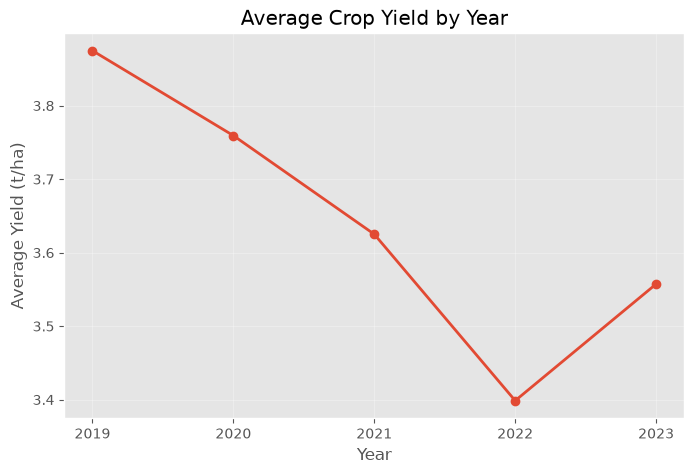

,Year,Yield_t_ha
0,2019,3.8700
1,2020,3.7600
2,2021,3.6300
3,2022,3.4000
4,2023,3.5600


In [15]:
# Average yield by year

yearly_yield = (
    df.groupby('Year')['Yield_t_ha']
      .mean()
      .reset_index()
)

plt.figure(figsize=(8,5))

plt.plot(
    yearly_yield['Year'],
    yearly_yield['Yield_t_ha'],
    marker='o',
    linewidth=2
)

plt.title('Average Crop Yield by Year')
plt.xlabel('Year')
plt.ylabel('Average Yield (t/ha)')
plt.xticks(yearly_yield['Year'])
plt.grid(alpha=0.3)

# Save figure
plt.savefig('../figures/yearly_yield_trend.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

display(yearly_yield.round(2))

## Temporal (Yearly) Trends Interpretation

The average crop yield showed a gradual decline from 3.87 t/ha in 2019 to 3.40 t/ha in 2022, before recovering slightly to 3.56 t/ha in 2023. Overall, the variation across years was relatively small, suggesting that there was no strong temporal trend in yield during the study period.

The slight decline between 2019 and 2022 may reflect the effects of varying weather conditions, particularly rainfall deficits and higher temperatures experienced in some years. The modest increase in 2023 indicates partial recovery in crop productivity. This observation is consistent with the correlation analysis, where Year exhibited a very weak negative correlation with yield (r = -0.03), indicating that year alone was not a strong predictor of crop yield.

## County-wise Trends

This analysis examines how crop yield varies across counties. Comparing the average yield by county helps identify high- and low-performing regions and reveals spatial differences in agricultural productivity.

The section includes:
- A horizontal bar chart showing the average yield for each county.
- Summary statistics of yield grouped by county.

These insights help determine whether geographic location contributes to variations in crop yield and can inform subsequent feature engineering and model development.

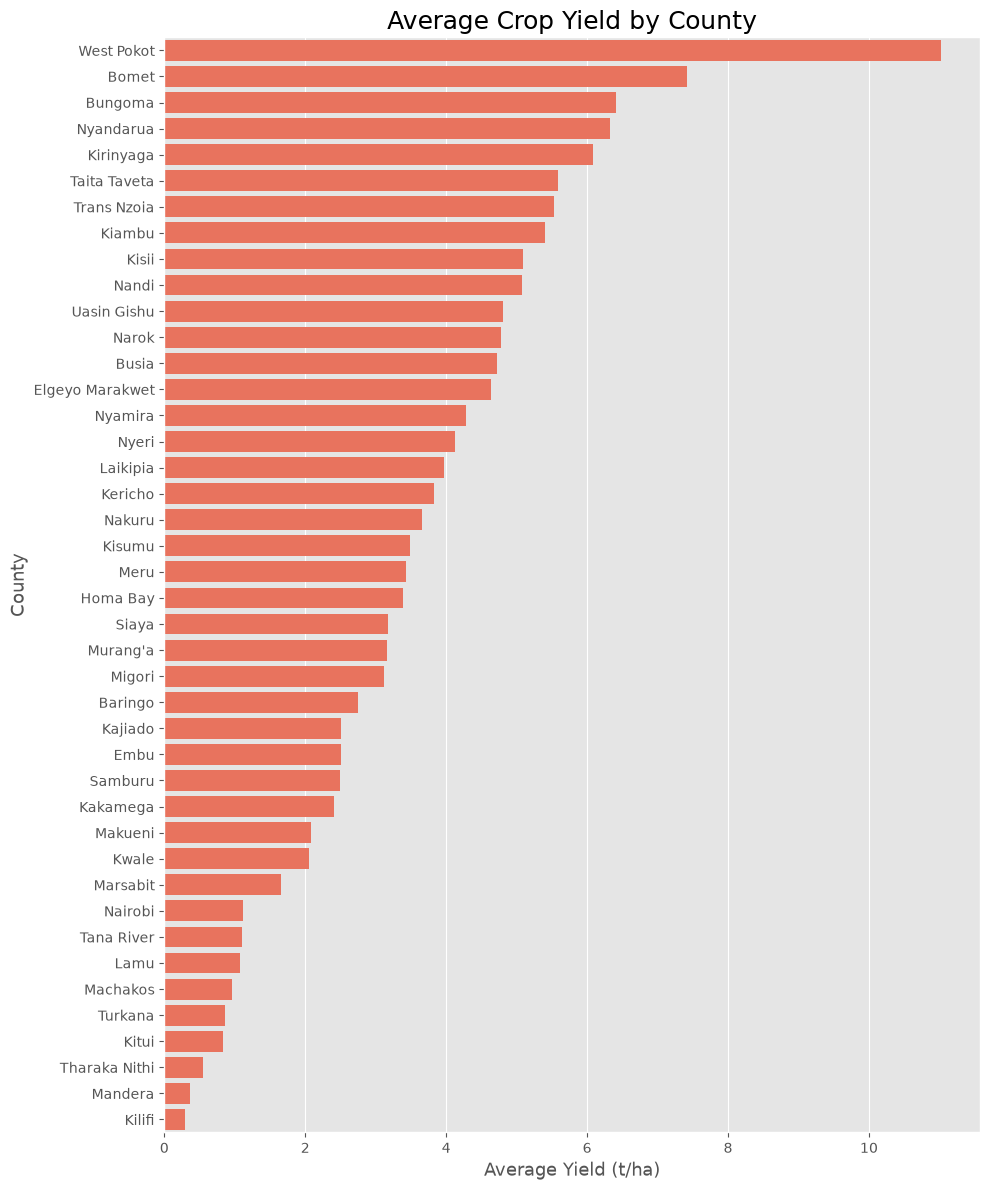

County-wise Yield Summary Statistics


,count,mean,median,std,min,max
County,,,,,,
West Pokot,5,11.0200,10.0000,2.4100,8.6800,14.7600
Bomet,20,7.4200,3.7900,7.1300,0.9600,20.2900
Bungoma,25,6.4100,3.1000,5.7100,0.5700,16.3500
Nyandarua,10,6.3300,4.2700,3.7500,2.8500,11.1100
Kirinyaga,15,6.0800,7.1200,4.8300,0.3200,12.5100
Taita Taveta,20,5.5800,0.6200,8.8900,0.0900,23.2300
Trans Nzoia,25,5.5300,3.8100,4.6300,0.3600,14.7800
Kiambu,15,5.4100,5.3400,3.7300,0.5500,11.2700
Kisii,15,5.0900,1.8200,5.8500,0.4800,15.3000


In [18]:
# County-wise average yield

county_yield = (
    df.groupby('County')['Yield_t_ha']
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(10, 12))

sns.barplot(
    data=county_yield,
    x='Yield_t_ha',
    y='County',
    color='tomato'
)

plt.title('Average Crop Yield by County', fontsize=18)
plt.xlabel('Average Yield (t/ha)', fontsize=13)
plt.ylabel('County', fontsize=13)

plt.tight_layout()

# Save figure
plt.savefig('../figures/countywise_average_yield.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

plt.show()

# Summary statistics by county
county_summary = (
    df.groupby('County')['Yield_t_ha']
      .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
      .round(2)
      .sort_values('mean', ascending=False)
)

print("County-wise Yield Summary Statistics")
display(county_summary)

## Interpretation for Countywise Average Yield

The county-wise analysis reveals considerable spatial variation in average crop yields across Kenya. West Pokot recorded the highest average yield (11.02 t/ha), followed by Bomet (7.42 t/ha), Bungoma (6.41 t/ha), Nyandarua (6.33 t/ha), and Kirinyaga (6.08 t/ha). Conversely, Kilifi (0.29 t/ha), Mandera (0.37 t/ha), Tharaka Nithi (0.56 t/ha), Kitui (0.83 t/ha), and Turkana (0.86 t/ha) recorded the lowest average yields.

The summary statistics also show substantial variability in yield within several counties. For example, Bomet, Taita Taveta, Busia, Nyamira, and Narok have relatively large standard deviations and wide ranges between minimum and maximum yields, indicating considerable differences across crops and years.

These county averages should be interpreted with caution because the dataset combines multiple crop types with inherently different yield potentials. Counties cultivating high-yield crops such as Irish potatoes and sweet potatoes are expected to have higher average yields than counties dominated by cereals or legumes. Consequently, differences in county averages reflect not only environmental and management conditions but also variations in crop composition.

Overall, the analysis demonstrates that crop productivity varies considerably across Kenya, highlighting the influence of local environmental conditions, agricultural practices, and the mix of crops cultivated within each county.